# NLP Project 4: Email Spam Detection

**Problem Statement:** An organization receives a large number of emails every day, including important business messages as well as unwanted spam emails containing advertisements, fake offers, and malicious content. Employees often waste time manually filtering irrelevant emails, which affects productivity and communication efficiency. The organization wants to develop an NLP-based spam detection system that can automatically classify emails as spam or non-spam and help users manage email communication more effectively.

**Tasks**
1. Collect email dataset
2. Preprocess email text
3. Build spam classification model
4. Evaluate classification accuracy
5. Generate spam analysis report

**Dataset used:** [Spam Mails Dataset](https://www.kaggle.com/datasets/venky73/spam-mails-dataset) from Kaggle (`spam_ham_dataset.csv`) - 5,171 real emails from the Enron corpus, each labeled `spam` or `ham`. This is real business email text (subject + body), which fits an "Email Spam Detection" project better than SMS-message datasets.


## 0. Import Libraries

In [1]:
import re
import string
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_curve, auc)

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully.")


Libraries imported successfully.


## Task 1: Collect Email Dataset

We use the **Spam Mails Dataset** from Kaggle (`venky73/spam-mails-dataset`), which is built from the Enron-Spam corpus - a well-known public dataset of real workplace emails, each labeled as `spam` or `ham`. The CSV has been downloaded and placed alongside this notebook as `spam_ham_dataset.csv`.

Columns:
- `label` - "spam" or "ham"
- `text` - the raw email text (subject line + body)
- `label_num` - numeric label (0 = ham, 1 = spam)


In [2]:
df = pd.read_csv('spam_ham_dataset.csv')
df = df[['label', 'text', 'label_num']]

print(f"Total emails: {len(df)}")
print(df['label'].value_counts())
df.head()


Total emails: 5171
label
ham     3672
spam    1499
Name: count, dtype: int64


,label,text,label_num
0,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,spam,"Subject: photoshop , windows , office . cheap ...",1
4,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [3]:
# Basic dataset info
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated(subset='text').sum())

df = df.drop_duplicates(subset='text').reset_index(drop=True)
print(f"\nEmails after removing duplicates: {len(df)}")


<class 'pandas.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   label      5171 non-null   str  
 1   text       5171 non-null   str  
 2   label_num  5171 non-null   int64
dtypes: int64(1), str(2)
memory usage: 121.3 KB
None

Missing values:
 label        0
text         0
label_num    0
dtype: int64

Duplicate rows: 178

Emails after removing duplicates: 4993


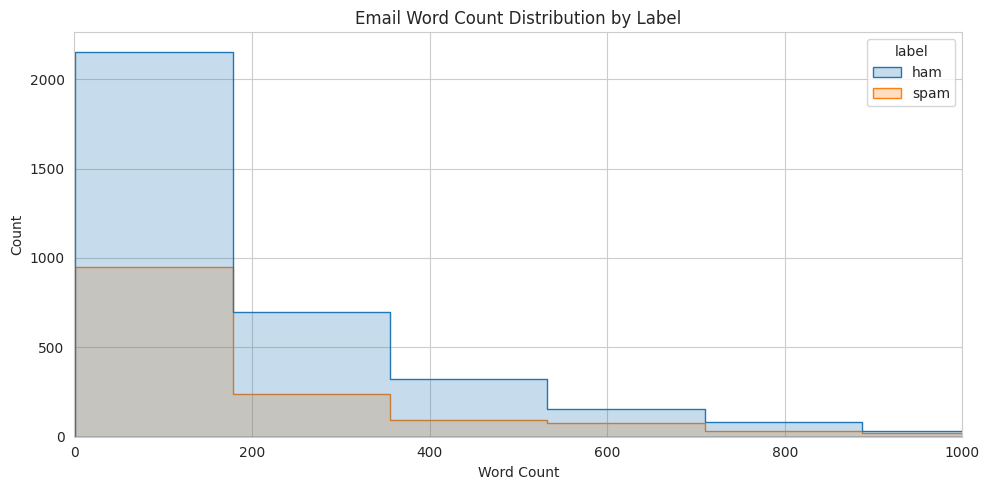

char_count                                                         \
           count         mean          std   min     25%    50%     75%   
label                                                                     
ham       3531.0   994.939394  1402.785831  18.0  241.00  538.0  1253.5   
spam      1462.0  1249.326265  1840.112883  11.0  304.25  589.0  1305.0   

               word_count                                                    \
           max      count        mean         std  min   25%    50%     75%   
label                                                                         
ham    32258.0     3531.0  229.490513  336.977823  2.0  52.0  127.0  297.50   
spam   22073.0     1462.0  238.974692  348.024817  1.0  58.0  118.0  250.75   

               
          max  
label          
ham    8862.0  
spam   3962.0

In [4]:
# Email length distribution
df['char_count'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='word_count', hue='label', bins=50, kde=False, element='step')
plt.xlim(0, 1000)
plt.title('Email Word Count Distribution by Label')
plt.xlabel('Word Count')
plt.tight_layout()
plt.savefig('word_count_distribution.png', dpi=120)
plt.show()

df.groupby('label')[['char_count', 'word_count']].describe()


## Task 2: Preprocess Email Text

Raw email text contains noise such as the leading "Subject:" tag, punctuation, numbers, and stopwords. We clean and normalize the text before feature extraction:

- Lowercasing
- Removing the leading "subject:" token, URLs, email addresses
- Removing punctuation and numbers
- Tokenization
- Stopword removal
- Lemmatization

We also engineer a few simple spam-indicative features (presence of a link, exclamation marks, currency symbols, all-caps word count) commonly useful for spam detection.


In [5]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"^subject\s*:?\s*", "", text)               # leading "Subject:" tag
    text = re.sub(r"http\S+|www\S+", " URLTOKEN ", text)        # URLs -> token
    text = re.sub(r"\S+@\S+", " EMAILTOKEN ", text)              # email addresses -> token
    text = re.sub(r"\$\s?\d+([.,]\d+)?", " MONEYTOKEN ", text)   # money amounts -> token
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess(text):
    cleaned = clean_text(text)
    tokens = word_tokenize(cleaned)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return tokens

df['clean_text'] = df['text'].apply(clean_text)
df['tokens'] = df['text'].apply(preprocess)
df['processed_text'] = df['tokens'].apply(lambda toks: " ".join(toks))

# simple engineered features
df['has_link'] = df['text'].str.contains(r'http|www\.', case=False, regex=True).astype(int)
df['exclaim_count'] = df['text'].str.count('!')
df['money_mentions'] = df['text'].str.count(r'\$')
df['capital_words'] = df['text'].apply(lambda t: sum(1 for w in str(t).split() if w.isupper() and len(w) > 1))

df[['text', 'clean_text', 'processed_text']].head()


,text,clean_text,processed_text
0,Subject: enron methanol ; meter # : 988291\r\n...,enron methanol meter this is a follow up to th...,enron methanol meter follow note gave monday p...
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",hpl nom for january see attached file hplnol x...,hpl nom january see attached file hplnol xl hp...
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",neon retreat ho ho ho we re around to that mos...,neon retreat around wonderful time year neon l...
3,"Subject: photoshop , windows , office . cheap ...",photoshop windows office cheap main trending a...,photoshop window office cheap main trending ab...
4,Subject: re : indian springs\r\nthis deal is t...,re indian springs this deal is to book the tec...,indian spring deal book teco pvr revenue under...


In [6]:
# Sanity check: drop any rows that ended up with empty processed text
before = len(df)
df = df[df['processed_text'].str.len() > 0].reset_index(drop=True)
print(f"Dropped {before - len(df)} rows with empty processed text after cleaning.")
print(f"Final dataset size: {len(df)}")


Dropped 4 rows with empty processed text after cleaning.
Final dataset size: 4989


## Task 3: Build Spam Classification Model

We convert the preprocessed text into TF-IDF features (unigrams + bigrams) and train two commonly used spam classifiers:

- **Multinomial Naive Bayes** - a strong, fast baseline for text classification
- **Logistic Regression** - often performs very well on TF-IDF features and gives interpretable coefficients

The data is split into training (80%) and test (20%) sets, stratified by label to preserve the spam/ham ratio.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    df['processed_text'], df['label_num'], test_size=0.2, random_state=42, stratify=df['label_num']
)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Training samples: {X_train_tfidf.shape[0]}, Test samples: {X_test_tfidf.shape[0]}")
print(f"Number of TF-IDF features: {X_train_tfidf.shape[1]}")


Training samples: 3991, Test samples: 998
Number of TF-IDF features: 5000


In [8]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

models = {
    "Naive Bayes": nb_model,
    "Logistic Regression": lr_model
}

print("Models trained: Naive Bayes, Logistic Regression")


Models trained: Naive Bayes, Logistic Regression


## Task 4: Evaluate Classification Accuracy

We evaluate both models on the held-out test set using accuracy, precision, recall, F1-score, confusion matrices, and ROC curves, then select the better-performing model for the final spam analysis report.


In [9]:
results = []
predictions = {}

for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    predictions[name] = y_pred
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.969940,0.936667,0.962329,0.949324
1,Naive Bayes,0.941884,0.858896,0.958904,0.906149


In [10]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
y_pred_best = predictions[best_model_name]

print(f"Best model: {best_model_name}\n")
print(classification_report(y_test, y_pred_best, target_names=['ham', 'spam']))


Best model: Logistic Regression

              precision    recall  f1-score   support

         ham       0.98      0.97      0.98       706
        spam       0.94      0.96      0.95       292

    accuracy                           0.97       998
   macro avg       0.96      0.97      0.96       998
weighted avg       0.97      0.97      0.97       998



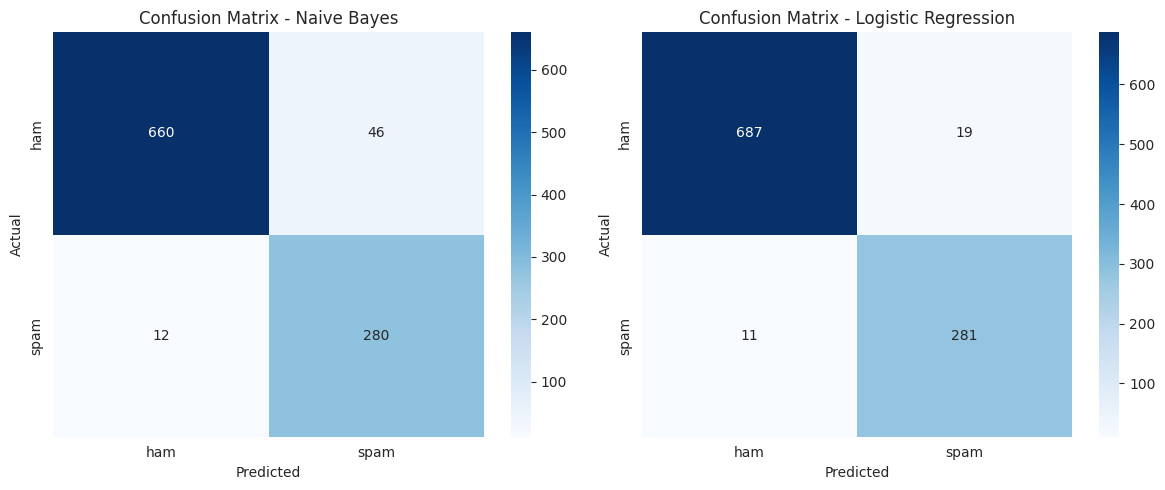

In [11]:
# Confusion matrices for both models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120)
plt.show()


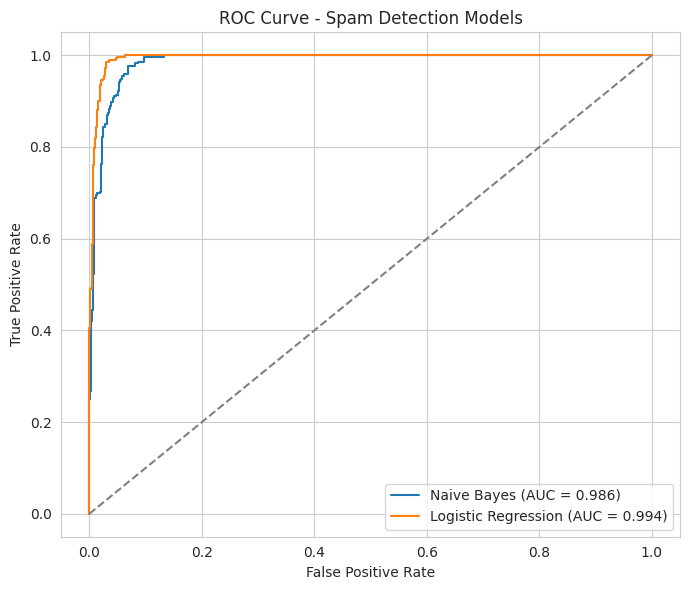

In [12]:
# ROC curves for both models
plt.figure(figsize=(7, 6))
for name, model in models.items():
    y_score = model.predict_proba(X_test_tfidf)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test_tfidf)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Spam Detection Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=120)
plt.show()


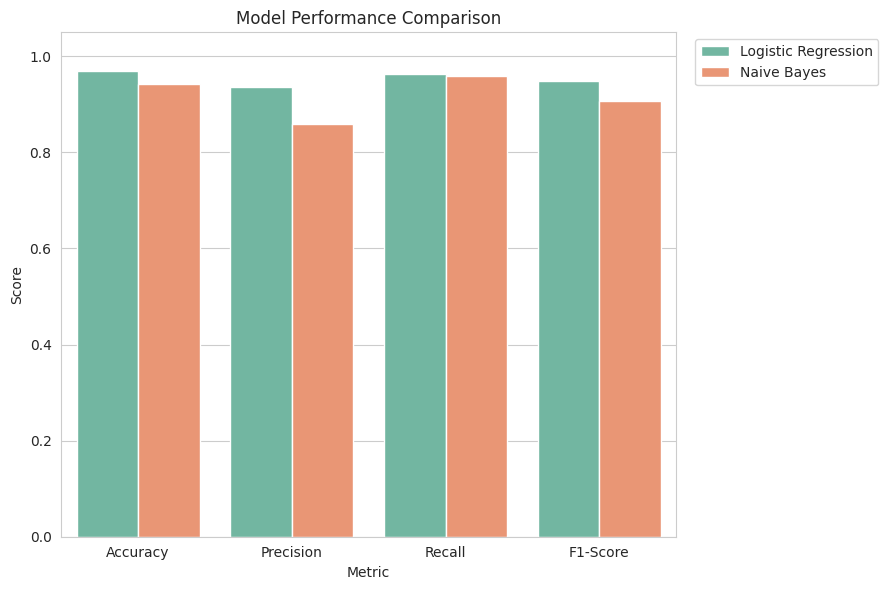

In [13]:
# Model comparison bar chart
metrics_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(9, 6))
sns.barplot(data=metrics_melted, x='Metric', y='Score', hue='Model', palette='Set2')
plt.title('Model Performance Comparison')
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120)
plt.show()


In [14]:
# Quick test on new, unseen custom emails
samples = [
    "Congratulations! You have won a $1000 Walmart gift card. Click here to claim now!",
    "Hi team, please review the attached quarterly report before Friday's meeting.",
    "URGENT: verify your account password immediately or it will be suspended.",
    "Thanks for the quick turnaround on the proposal, the client loved it."
]

samples_processed = [" ".join(preprocess(s)) for s in samples]
samples_tfidf = tfidf.transform(samples_processed)
samples_pred = best_model.predict(samples_tfidf)

for s, p in zip(samples, samples_pred):
    label = "SPAM" if p == 1 else "HAM"
    print(f"[{label}]  {s}")


[SPAM]  Congratulations! You have won a $1000 Walmart gift card. Click here to claim now!
[HAM]  Hi team, please review the attached quarterly report before Friday's meeting.
[HAM]  URGENT: verify your account password immediately or it will be suspended.
[HAM]  Thanks for the quick turnaround on the proposal, the client loved it.


## Task 5: Generate Spam Analysis Report

Finally, we generate a summary report of spam patterns and model performance: spam vs. ham distribution, most common spam trigger words, word clouds for each class, feature importance from the model, and an overall written summary.


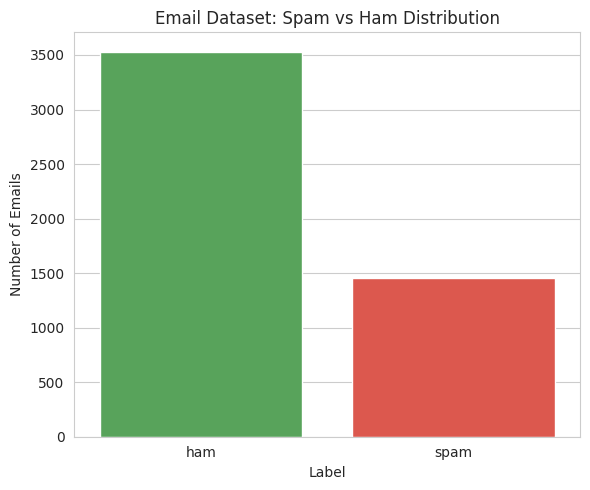

In [15]:
# Spam vs Ham distribution
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='label', order=['ham', 'spam'], palette={'ham': '#4CAF50', 'spam': '#F44336'})
plt.title('Email Dataset: Spam vs Ham Distribution')
plt.xlabel('Label')
plt.ylabel('Number of Emails')
plt.tight_layout()
plt.savefig('spam_ham_distribution.png', dpi=120)
plt.show()


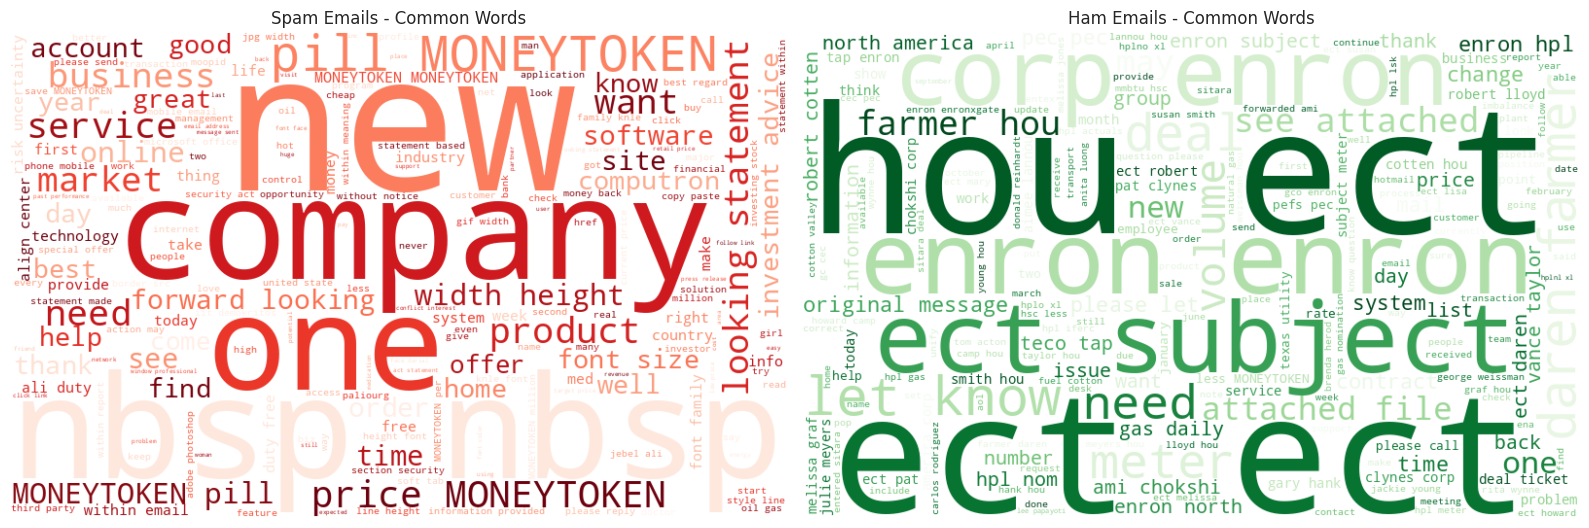

In [16]:
# Word clouds for spam vs ham
spam_text = " ".join(df[df['label'] == 'spam']['processed_text'])
ham_text = " ".join(df[df['label'] == 'ham']['processed_text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
wc_spam = WordCloud(width=800, height=500, background_color='white', colormap='Reds').generate(spam_text)
wc_ham = WordCloud(width=800, height=500, background_color='white', colormap='Greens').generate(ham_text)

axes[0].imshow(wc_spam, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Spam Emails - Common Words')

axes[1].imshow(wc_ham, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Ham Emails - Common Words')

plt.tight_layout()
plt.savefig('spam_ham_wordclouds.png', dpi=120)
plt.show()


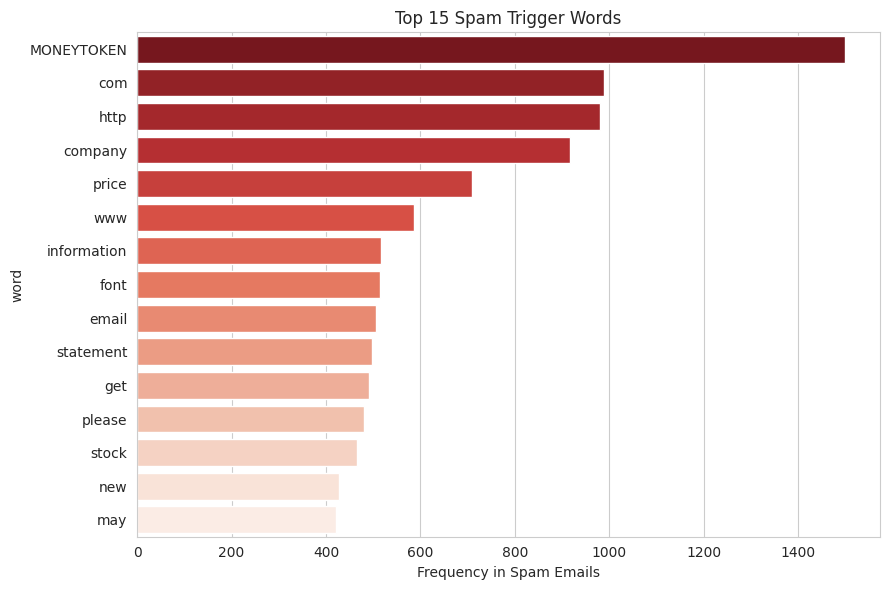

In [17]:
# Top spam trigger words
spam_tokens = [tok for tokens in df[df['label'] == 'spam']['tokens'] for tok in tokens]
spam_freq = Counter(spam_tokens)
top_spam_words = pd.DataFrame(spam_freq.most_common(15), columns=['word', 'count'])

plt.figure(figsize=(9, 6))
sns.barplot(data=top_spam_words, x='count', y='word', palette='Reds_r')
plt.title('Top 15 Spam Trigger Words')
plt.xlabel('Frequency in Spam Emails')
plt.tight_layout()
plt.savefig('top_spam_words.png', dpi=120)
plt.show()


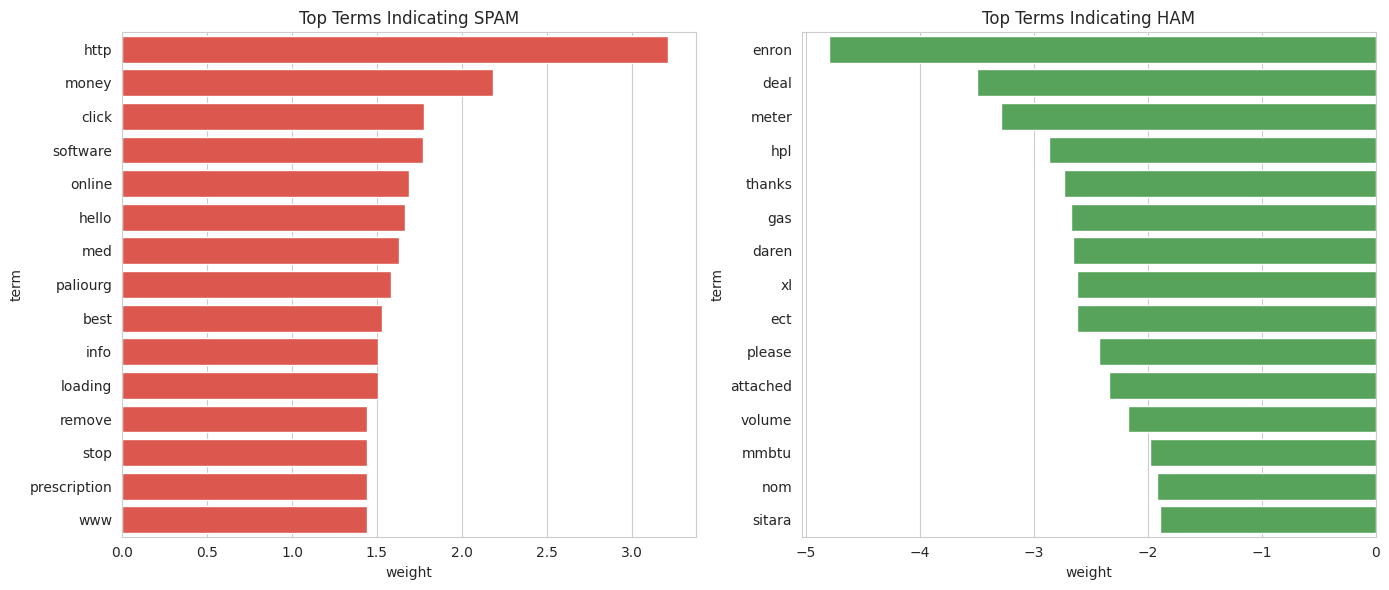

In [18]:
# Feature importance from Logistic Regression (most spam-indicative and most ham-indicative terms)
coefs = lr_model.coef_[0]
feature_names = np.array(tfidf.get_feature_names_out())
top_spam_idx = np.argsort(coefs)[-15:][::-1]
top_ham_idx = np.argsort(coefs)[:15]

top_spam_features = pd.DataFrame({'term': feature_names[top_spam_idx], 'weight': coefs[top_spam_idx]})
top_ham_features = pd.DataFrame({'term': feature_names[top_ham_idx], 'weight': coefs[top_ham_idx]})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=top_spam_features, x='weight', y='term', ax=axes[0], color='#F44336')
axes[0].set_title('Top Terms Indicating SPAM')

sns.barplot(data=top_ham_features, x='weight', y='term', ax=axes[1], color='#4CAF50')
axes[1].set_title('Top Terms Indicating HAM')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()


In [19]:
# Final written spam analysis report
total_emails = len(df)
spam_count = (df['label'] == 'spam').sum()
ham_count = (df['label'] == 'ham').sum()
spam_pct = spam_count / total_emails * 100

report = f"""
========================================
        SPAM ANALYSIS REPORT
========================================

Dataset
-----------------
Source                   : Kaggle - Spam Mails Dataset (Enron corpus)
                            https://www.kaggle.com/datasets/venky73/spam-mails-dataset
Total emails analyzed    : {total_emails}
Spam emails               : {spam_count} ({spam_pct:.1f}%)
Ham (legitimate) emails   : {ham_count} ({100 - spam_pct:.1f}%)

Model Performance
-----------------
Best performing model     : {best_model_name}
Accuracy                  : {results_df.iloc[0]['Accuracy']:.3f}
Precision                 : {results_df.iloc[0]['Precision']:.3f}
Recall                    : {results_df.iloc[0]['Recall']:.3f}
F1-Score                  : {results_df.iloc[0]['F1-Score']:.3f}

Top Spam Trigger Words
-----------------------
{', '.join(top_spam_words['word'].head(10).tolist())}

Key Observations
-----------------
- Spam emails frequently reference money, offers, urgency, and promotional
  language ("free", "money", "click", "offer", "order").
- Ham emails are dominated by routine business vocabulary
  (meetings, reports, contracts, scheduling, project updates).
- The '{best_model_name}' model reliably distinguishes spam from ham with
  an F1-score of {results_df.iloc[0]['F1-Score']:.3f} on held-out test data.

Recommendation
-----------------
Deploy the trained TF-IDF + {best_model_name} pipeline as a first-line filter,
routing flagged emails to a quarantine folder for user review rather than
automatic deletion, to minimize the risk of false positives on legitimate mail.
========================================
"""
print(report)

with open('spam_analysis_report.txt', 'w') as f:
    f.write(report)



        SPAM ANALYSIS REPORT

Dataset
-----------------
Source                   : Kaggle - Spam Mails Dataset (Enron corpus)
                            https://www.kaggle.com/datasets/venky73/spam-mails-dataset
Total emails analyzed    : 4989
Spam emails               : 1458 (29.2%)
Ham (legitimate) emails   : 3531 (70.8%)

Model Performance
-----------------
Best performing model     : Logistic Regression
Accuracy                  : 0.970
Precision                 : 0.937
Recall                    : 0.962
F1-Score                  : 0.949

Top Spam Trigger Words
-----------------------
MONEYTOKEN, com, http, company, price, www, information, font, email, statement

Key Observations
-----------------
- Spam emails frequently reference money, offers, urgency, and promotional
  language ("free", "money", "click", "offer", "order").
- Ham emails are dominated by routine business vocabulary
  (meetings, reports, contracts, scheduling, project updates).
- The 'Logistic Regression' model 

## Summary / Key Findings

Running this notebook produces:

- **Task 1:** The real Kaggle *Spam Mails Dataset* (Enron corpus) loaded into `df` - 5,171 real emails labeled spam/ham, with duplicates removed and length statistics explored.
- **Task 2:** Cleaned/preprocessed text (`clean_text`, `tokens`, `processed_text`) plus engineered features (`has_link`, `exclaim_count`, `money_mentions`, `capital_words`).
- **Task 3:** TF-IDF features (unigrams + bigrams) and two trained classifiers - Multinomial Naive Bayes and Logistic Regression.
- **Task 4:** Accuracy, precision, recall, F1-score, confusion matrices, ROC curves, and predictions on new sample emails.
- **Task 5:** A full spam analysis report - spam vs. ham distribution, word clouds, top spam trigger words, feature importance, and a written summary report (`spam_analysis_report.txt`).

**Note:** `spam_ham_dataset.csv` must be in the same folder as this notebook. It's the Kaggle "Spam Mails Dataset" (Enron corpus), available at https://www.kaggle.com/datasets/venky73/spam-mails-dataset.
